# MORS 多峰分辨可行性验证 — RF 线圈扫频法 (v1)

**实验目的**：用 RF 线圈直接驱动横向自旋，在不同 B 场下测量 MORS 单峰线宽 Γ，
与 v2 (Bell-Bloom 泵浦调制扫频) 对照，检验非线性塞曼效应的复合谱模型是否成立。

**v1 vs v2 的本质区别**：

| | v1: RF 线圈扫频 (本实验) | v2: Pump 调制扫频 |
|---|---|---|
| **激发机制** | RF 线圈 (Y) 直接驱动 Δm=±1 跃迁 | Pump 脉冲与进动同步共振 |
| **4-Lorentzian 叠加模型** | 应成立 (RF 独立驱动每个相干) | 存疑 (非线性同步可能不叠加) |
| **预期 SNR** | 低 (探测扰动 δS，非全极化) | 高 (探测全极化共振包络) |

**为什么这个对照关键**：v2 测量结果显示 Γ 在 B 增大时不展宽，与 4-Lorentzian 叠加
模型的预测矛盾。如果 v1 的 Γ 也随 B 不变 → 非线性塞曼效应本身可能比预期小。
如果 v1 的 Γ 随 B 增长 → Bell-Bloom 的同步机制抑制了多峰叠加。

**测量方法**：
1. CW Pump 维持稳态极化，RF 线圈沿 Y 施加弱正弦波
2. RF 频率在 ν_L 附近扫频，LIA (ref=ν_L) 解调 → R(f) = MORS 谱
3. 扫描 B 场 (10-90 mA，与 v2 对齐)，每点拟合 Γ

**涉及设备**：
- GS200：主磁场 (10-90 mA)
- DG912 Pro：Pump 光功率 (CH1 DC)、Probe 光功率 (CH2 DC)
- DG4000 (#1 调制)：Pump_modulation CH1=100MHz CW + Time_sequence CH2=DC 5V
- DG4000 (#2 RF 线圈)：RF 线圈驱动 (CH2, Y 方向)，正弦波扫频
- DG4000 (#3 温控)：温度开关 CH2
- HF2：锁相放大器，参考频率跟踪 ν_L
- TEC103：气室温度控制

In [53]:
# ========== 交互式绘图模式 ==========
%matplotlib widget

from pathlib import Path
import sys
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
from datetime import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit

# 设备库
from gs200 import GS200Instrument
from signal_generator import DG4000Instrument, DG900Instrument
from tec_controller import TECInstrument
from lockin_amplifier import (
    HF2Instrument, DemodulatorConfig, demod,
)

print("所有库导入成功")

所有库导入成功


In [54]:
# ========== 加载配置 ==========

with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]
with open(project_root / "params" / "safety_limits.yaml", encoding="utf-8") as f:
    LIMITS = yaml.safe_load(f)["safety_limits"]

# ========== 物理常数 ==========
GYRO_RATIO = 700e3          # 87Rb F=2 旋磁比 (Hz/G)
NU_HFS = 6.835e9            # 87Rb 基态超精细分裂 (Hz)

# ========== 线圈常数（2026-05 标定）==========
COIL_CONSTANT = 9670.0      # Hz/mA
NU_RESIDUAL = 0.0           # Hz

# ========== 实验参数 ==========
EXPERIMENT_TYPE = "MORS_feasibility"
PURPOSE = "linewidth_vs_B_rf_coil"

# ---- Pump 光 ----
PUMP_POWER = 0.02               # Pump 光功率 (V)，CW 维持极化

# ---- Probe 光 ----
PROBE_POWER = 0.05              # Probe 光功率 (V)，CW

# ---- 主磁场扫描 (与 v2 对齐) ----
B_CURRENT_mA = np.array([10.0, 30.0, 50.0, 70.0, 90.0])

# ---- RF 扫频参数 ----
RF_SWEEP_HALF_SPAN = 2000      # RF 扫频半宽 (Hz)，与 v2 对齐
RF_SWEEP_POINTS = 101
RF_AMPLITUDE = 0.05           # RF 幅度 (V)，v1 需要更强的 RF 才有足够 SNR

# ---- LIA 参数 ----
HF2_DEMOD_IDX = 0
HF2_SIGNAL_RANGE = 2.0
HF2_DEMOD_ORDER = 4
HF2_DEMOD_TC = 0.003           # LIA 时间常数 (s)，加长以压制噪声
HF2_DEMOD_RATE = 10000
SETTLE_MULTIPLIER = 20         # 每频点等待 TC 倍数
N_SAMPLES_PER_POINT = 20       # 每频点采样数 (RF 信号弱，需更多平均)

# ---- 温度 ----
TEC_TEMPERATURE = 100.0
TEMP_SW_V = 5.0

# ========== 运行目录 ==========
RUN_TAG = "linewidth_vs_B_rf"

def validate_safety_limit(name, value):
    lim = LIMITS.get(name)
    if lim is None:
        return value
    lo, hi = lim["min"], lim["max"]
    if value is not None and (value < lo or value > hi):
        raise ValueError(f"[安全拦截] {name}={value} 超出范围 [{lo}, {hi}]")
    return value

for i_ma in B_CURRENT_mA:
    validate_safety_limit("main_magnetic_field", float(i_ma))

def calc_nu_L(I_mA):
    return COIL_CONSTANT * I_mA + NU_RESIDUAL

print("配置加载完成")
print(f"  线圈常数: {COIL_CONSTANT:.1f} Hz/mA")
print(f"  B 扫描电流: {B_CURRENT_mA} mA")
print(f"  预期 nu_L 范围: {calc_nu_L(B_CURRENT_mA[0])/1000:.1f} ~ {calc_nu_L(B_CURRENT_mA[-1])/1000:.1f} kHz")
print(f"  RF 幅度: {RF_AMPLITUDE} V, TC: {HF2_DEMOD_TC*1e3:.0f} ms")
print(f"  扫频半宽: +/-{RF_SWEEP_HALF_SPAN} Hz, {RF_SWEEP_POINTS} 点")
print(f"  每点等待: {SETTLE_MULTIPLIER}xTC={SETTLE_MULTIPLIER*HF2_DEMOD_TC*1e3:.0f} ms, 采样: {N_SAMPLES_PER_POINT} 次")

配置加载完成
  线圈常数: 9670.0 Hz/mA
  B 扫描电流: [10. 30. 50. 70. 90.] mA
  预期 nu_L 范围: 96.7 ~ 870.3 kHz
  RF 幅度: 0.05 V, TC: 3 ms
  扫频半宽: +/-2000 Hz, 101 点
  每点等待: 20xTC=60 ms, 采样: 20 次


In [55]:
# ========== 连接设备 ==========

devices = {}

try:
    # ---- GS200: 主磁场 ----
    gs_cfg = MAPPING["main_magnetic_field"]
    gs = GS200Instrument(gs_cfg["resource"])
    gs.connect()
    print(f"GS200 已连接: {gs.idn()}")
    gs.set_source_function(gs_cfg["source_function"])
    gs.set_current_limit(LIMITS["main_magnetic_field"]["max"] / 1000.0)
    devices["gs200"] = gs

    # ---- DG912 Pro: Pump/Probe 光功率 ----
    dg_laser_cfg = MAPPING["Pump_laser_power"]
    dg_laser = DG900Instrument(dg_laser_cfg["resource"], channel=1)
    dg_laser.connect()
    print(f"光功率 DG912 Pro 已连接: {dg_laser.idn()}")
    dg_laser.set_ref_clock_source("EXTernal")
    devices["dg_laser"] = dg_laser

    # ---- DG4000: RF 线圈驱动 (Y 方向, CH2) ----
    rf_cfg = MAPPING["rf_coil"]
    dg_rf = DG4000Instrument(rf_cfg["resource"], channel=rf_cfg["channel"])
    dg_rf.connect()
    print(f"RF 线圈 DG4000 已连接: {dg_rf.idn()}")
    devices["dg_rf"] = dg_rf

    # ---- DG4000: 调制 (Pump_modulation CH1 + Time_sequence CH2) ----
    mod_cfg = MAPPING["Pump_modulation"]
    dg_mod = DG4000Instrument(mod_cfg["resource"], channel=mod_cfg["channel"])
    dg_mod.connect()
    print(f"调制 DG4000 已连接: {dg_mod.idn()}")
    devices["dg_mod"] = dg_mod

    # ---- DG4000: 温控 (温度开关 CH2) ----
    temp_sw_cfg = MAPPING["Temp_Switch"]
    dg_temp = DG4000Instrument(temp_sw_cfg["resource"], channel=temp_sw_cfg["channel"])
    dg_temp.connect()
    print(f"温控 DG4000 已连接: {dg_temp.idn()}")
    devices["dg_temp"] = dg_temp

    # ---- TEC103: 温度控制器 ----
    tec_cfg = MAPPING["temperature"]
    tec = TECInstrument(port=tec_cfg["resource"])
    tec.connect()
    print(f"TEC103 已连接")
    devices["tec"] = tec

    # ---- HF2: 锁相放大器 ----
    hf2_cfg = MAPPING["lockin_r"]
    hfi = HF2Instrument(
        host=hf2_cfg.get("host", "127.0.0.1"),
        port=hf2_cfg.get("port", 8005),
        api_level=1,
        device_id=hf2_cfg["device_id"],
    )
    hfi.connect()
    print(f"HF2 已连接: {hfi.idn}")
    hfi.set_extclk(True)
    print(f"  -> HF2 时钟源: 外部")
    devices["hf2"] = hfi

except Exception as e:
    print(f"设备连接失败: {e}")
    raise

print(f"\n所有设备连接完成，共 {len(devices)} 个设备")

GS200 已连接: YOKOGAWA,GS210,90Z631552,2.02
光功率 DG912 Pro 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q280100002,00.02.01.00.02
RF 线圈 DG4000 已连接: Rigol Technologies,DG4162,DG4E234902522,00.01.14
调制 DG4000 已连接: Rigol Technologies,DG4162,DG4E222800868,00.01.14
温控 DG4000 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q271200104,00.02.00.00.05
TEC103 已连接
HF2 已连接: HF2LI
  -> HF2 时钟源: 外部

所有设备连接完成，共 7 个设备


In [56]:
# ========== 设置初始值并创建运行目录 ==========

# ---- 1. Pump 光功率 (DC) ----
validate_safety_limit("Pump_laser_power", PUMP_POWER)
dg_laser.setup_dc(PUMP_POWER, channel=1)
dg_laser.set_output(True, channel=1)
print(f"Pump 光功率: CH1={PUMP_POWER} V (ON)")

# ---- 2. Probe 光功率 (DC) ----
validate_safety_limit("Probe_laser_power", PROBE_POWER)
dg_laser.setup_dc(PROBE_POWER, channel=2)
dg_laser.set_output(True, channel=2)
print(f"Probe 光功率: CH2={PROBE_POWER} V (ON)")

# ---- 3. Pump 调制: CH1=100MHz CW, CH2=DC 5V (CW 泵浦) ----
# CH1: 100MHz 连续正弦波 → RF 开关 IN → AOM (Pump 光强度调制)
# CH2: DC 5V → RF 开关 CTRL → 常开，使 100MHz CW 持续通过
PUMP_MOD_AMPLITUDE = 0.18       # 100MHz 正弦波幅度 (V)，CW 模式
PUMP_MOD_FREQ = 100e6          # 100 MHz 载波
validate_safety_limit("Pump_modulation", PUMP_MOD_AMPLITUDE)
dg_mod.setup_sine(freq=PUMP_MOD_FREQ, amplitude=PUMP_MOD_AMPLITUDE, offset=0.0, channel=1)
dg_mod.set_output(True, channel=1)
print(f"Pump 调制 CH1: {PUMP_MOD_FREQ/1e6:.0f} MHz, {PUMP_MOD_AMPLITUDE} Vpp (ON)")

TIME_SEQ_DC = 5.0              # DC 5V 保持 RF 开关常开
validate_safety_limit("Time_sequence", TIME_SEQ_DC)
dg_mod.setup_dc(TIME_SEQ_DC, channel=2)
dg_mod.set_output(True, channel=2)
print(f"Pump 调制 CH2 (Time_sequence): DC {TIME_SEQ_DC} V (CW 模式)")

# ---- 4. 温度开关 (初始 ON) ----
TEMP_SW_V = 5.0                # 5V=ON, 0V=OFF
validate_safety_limit("Temp_Switch", TEMP_SW_V)
dg_temp.setup_dc(TEMP_SW_V, channel=2)
dg_temp.set_output(True, channel=2)
print(f"温度开关: ON ({TEMP_SW_V} V)")

# ---- 5. 主磁场初始值（扫描起始值）----
validate_safety_limit("main_magnetic_field", float(B_CURRENT_mA[0]))
gs.set_current(B_CURRENT_mA[0] / 1000.0)
gs.set_output(True)
print(f"主磁场: {B_CURRENT_mA[0]} mA (初始值)")

# ---- 6. 温度控制 ----
validate_safety_limit("temperature", TEC_TEMPERATURE)
tec.set_target_temperature(TEC_TEMPERATURE, channel=1)
tec.set_enable(True, channel=1)
temp_now = tec.get_temperature(channel=1)
print(f"温度设定: {TEC_TEMPERATURE} °C, 当前: {temp_now:.1f} °C")
print("等待温度稳定...")
while True:
    time.sleep(5)
    t = tec.get_temperature(channel=1)
    print(f"  当前温度: {t:.2f} °C")
    if abs(t - TEC_TEMPERATURE) < 1:
        print(f"温度已稳定: {t:.2f} °C")
        break

# ---- 7. RF 线圈初始配置 (CW 正弦波，关闭输出) ----
nu_L_initial = calc_nu_L(B_CURRENT_mA[0])  # Hz
validate_safety_limit("rf_coil", RF_AMPLITUDE)
dg_rf.setup_sine(freq=nu_L_initial, amplitude=RF_AMPLITUDE, offset=0.0)
dg_rf.set_output(False)  # 先关闭，采集时再开
print(f"RF 线圈初始配置: {nu_L_initial/1000:.1f} kHz, {RF_AMPLITUDE} Vpp (输出 OFF)")

# ---- 8. 配置 HF2 解调器 ----
demod.set_reference_frequency(hfi, nu_L_initial, osc_idx=0)
demod_cfg = DemodulatorConfig(
    demod_index=HF2_DEMOD_IDX, enable=True,
    rate=HF2_DEMOD_RATE, input_channel=0,
    osc_select=0, harmonic=1,
    time_constant=HF2_DEMOD_TC, order=HF2_DEMOD_ORDER,
)
actual_rate = demod.configure_demodulator(hfi, demod_cfg)
print(f"HF2 解调器 {HF2_DEMOD_IDX} 已配置: Rate={actual_rate:.0f} Sa/s, TC={HF2_DEMOD_TC*1e3:.1f} ms")
print(f"  参考频率: {nu_L_initial/1000:.1f} kHz")

# ========== 创建运行目录 ==========
timestamp = datetime.now().strftime("%m%d_%H%M")
run_dir = project_root / "data" / EXPERIMENT_TYPE / f"{timestamp}_{RUN_TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
raw_dir = run_dir / "raw"
raw_dir.mkdir(exist_ok=True)
results_dir = run_dir / "results"
results_dir.mkdir(exist_ok=True)
print(f"运行目录: {run_dir}")

# ========== 保存实验配置 ==========
config = {
    "experiment_type": EXPERIMENT_TYPE,
    "purpose": PURPOSE,
    "timestamp": timestamp,
    "constants": {
        "gyro_ratio_Hz_per_G": GYRO_RATIO,
        "nu_hfs_Hz": NU_HFS,
        "coil_constant_Hz_per_mA": COIL_CONSTANT,
        "nu_residual_Hz": NU_RESIDUAL,
    },
    "scan_params": {
        "b_current_mA": B_CURRENT_mA.tolist(),
        "rf_sweep_half_span_Hz": RF_SWEEP_HALF_SPAN,
        "rf_sweep_points": RF_SWEEP_POINTS,
        "rf_amplitude_V": RF_AMPLITUDE,
    },
    "fixed_params": {
        "pump_power_V": PUMP_POWER,
        "probe_power_V": PROBE_POWER,
        "pump_mod_MHz": PUMP_MOD_FREQ / 1e6,
        "pump_mod_amplitude_V": PUMP_MOD_AMPLITUDE,
        "time_sequence_DC_V": TIME_SEQ_DC,
        "temp_switch_V": TEMP_SW_V,
        "temperature_C": TEC_TEMPERATURE,
    },
    "hf2_demod": {
        "demod_idx": HF2_DEMOD_IDX,
        "tc_s": HF2_DEMOD_TC,
        "order": HF2_DEMOD_ORDER,
        "rate_Sa_s": HF2_DEMOD_RATE,
        "actual_rate_Sa_s": actual_rate,
        "settle_multiplier": SETTLE_MULTIPLIER,
    },
}
config_path = run_dir / "experiment_config.yaml"
with open(config_path, "w", encoding="utf-8") as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)
print(f"实验配置已保存: {config_path}")

print("\n初始值设置完成，等待 Pump 光极化建立 (~5×T₁)...")
time.sleep(1.0)  # T₁ ~ 30 ms → 等 1s 足够

Pump 光功率: CH1=0.02 V (ON)
Probe 光功率: CH2=0.05 V (ON)
Pump 调制 CH1: 100 MHz, 0.18 Vpp (ON)
Pump 调制 CH2 (Time_sequence): DC 5.0 V (CW 模式)
温度开关: ON (5.0 V)
主磁场: 10.0 mA (初始值)
温度设定: 100.0 °C, 当前: 100.5 °C
等待温度稳定...
  当前温度: 100.81 °C
温度已稳定: 100.81 °C
RF 线圈初始配置: 96.7 kHz, 0.05 Vpp (输出 OFF)
HF2 解调器 0 已配置: Rate=7196 Sa/s, TC=3.0 ms
  参考频率: 96.7 kHz
运行目录: d:\Code\exp_agent\data\MORS_feasibility\0528_1626_linewidth_vs_B_rf
实验配置已保存: d:\Code\exp_agent\data\MORS_feasibility\0528_1626_linewidth_vs_B_rf\experiment_config.yaml

初始值设置完成，等待 Pump 光极化建立 (~5×T₁)...


In [57]:
# =====================================================================
# RF 线性区验证: 固定 B=50mA，扫描 RF 幅度 → 确认无功率展宽
# =====================================================================

print("=" * 60)
print("RF 线性区验证 (fixed B=50mA, sweep RF amplitude)")
print("=" * 60)

I_verify = 50.0
nu_L_verify = calc_nu_L(I_verify)
RF_AMP_TEST = [0.2, 0.5, 1.0, 1.5, 2]  # Vpp

print(f"  B = {I_verify} mA, nu_L = {nu_L_verify/1000:.1f} kHz")
print(f"  RF 幅度扫描: {RF_AMP_TEST} V")

# 设置 B 场
validate_safety_limit("main_magnetic_field", I_verify)
gs.set_current(I_verify / 1000.0)
time.sleep(0.5)

# 设置 HF2 参考
demod.set_reference_frequency(hfi, nu_L_verify, osc_idx=0)
time.sleep(0.1)

# 窄扫频快速测峰
verify_freqs = np.linspace(nu_L_verify - 200, nu_L_verify + 200, 51)

# 局部 Lorentzian
def _lor(f, A, f0, G, o):
    h = G/2.0; return A*h**2/((f-f0)**2+h**2)+o

verify_results = []
verify_traces = []  # 保存原始谱用于画图

for amp in RF_AMP_TEST:
    validate_safety_limit("rf_coil", amp)

    dg_rf.setup_sine(freq=verify_freqs[0], amplitude=amp, offset=0.0)
    dg_rf.set_output(True)

    # 温度开关关一次
    dg_temp.set_output(False, channel=2)
    r_trace = np.full(len(verify_freqs), np.nan)
    for j, f in enumerate(verify_freqs):
        dg_rf.set_frequency(f)
        demod.set_reference_frequency(hfi, f, osc_idx=0)
        time.sleep(SETTLE_MULTIPLIER * HF2_DEMOD_TC)
        samples = [demod.read_demod_sample(hfi, demod_idx=HF2_DEMOD_IDX)["r"]
                   for _ in range(N_SAMPLES_PER_POINT)]
        r_trace[j] = np.mean(samples)
    # 恢复温度开关
    dg_temp.set_output(True, channel=2)
    dg_rf.set_output(False)
    time.sleep(1)

    verify_traces.append({"amp": amp, "freqs": verify_freqs.copy(), "r": r_trace.copy()})

    # Lorentzian 拟合
    valid = ~np.isnan(r_trace)
    f_v, r_v = verify_freqs[valid], r_trace[valid]
    if len(f_v) >= 10:
        r_max = np.max(r_v); f_peak = f_v[np.argmax(r_v)]
        off = np.median(r_v[:5]); A0 = r_max - off
        half = r_v > off + A0*0.5
        fwhm_est = f_v[half][-1] - f_v[half][0] if np.sum(half) >= 2 else 500
        p0 = [A0, f_peak, max(fwhm_est,10), off]
        try:
            popt, _ = curve_fit(_lor, f_v, r_v, p0=p0,
                                bounds=([0,f_v[0],10,0],[r_max*10,f_v[-1],5000,r_max]),
                                maxfev=5000)
            verify_results.append({
                "RF_amp_V": amp, "R_peak_V": r_max, "Gamma_Hz": popt[2],
                "f0_Hz": popt[1], "offset": popt[3], "A": popt[0],
            })
        except:
            verify_results.append({"RF_amp_V": amp, "R_peak_V": r_max, "Gamma_Hz": np.nan,
                                   "f0_Hz": np.nan, "offset": np.nan, "A": np.nan})
    else:
        verify_results.append({"RF_amp_V": amp, "R_peak_V": np.nan, "Gamma_Hz": np.nan,
                               "f0_Hz": np.nan, "offset": np.nan, "A": np.nan})

# 恢复温度开关和 RF
dg_temp.set_output(True, channel=2)
dg_rf.set_output(False)

RF 线性区验证 (fixed B=50mA, sweep RF amplitude)
  B = 50.0 mA, nu_L = 483.5 kHz
  RF 幅度扫描: [0.2, 0.5, 1.0, 1.5, 2] V



  RF(V)    R_peak(V)   Gamma(Hz)    f0(kHz)
---------------------------------------------
  0.200   3.8388e-05       344.0    483.516
  0.500   9.1681e-05       370.9    483.490
  1.000   1.8101e-04       215.2    483.552
  1.500   2.3553e-04       359.7    483.545
  2.000   3.2008e-04       481.7    483.574

  -> Gamma 变化 2.24x，需判断是否功率展宽。


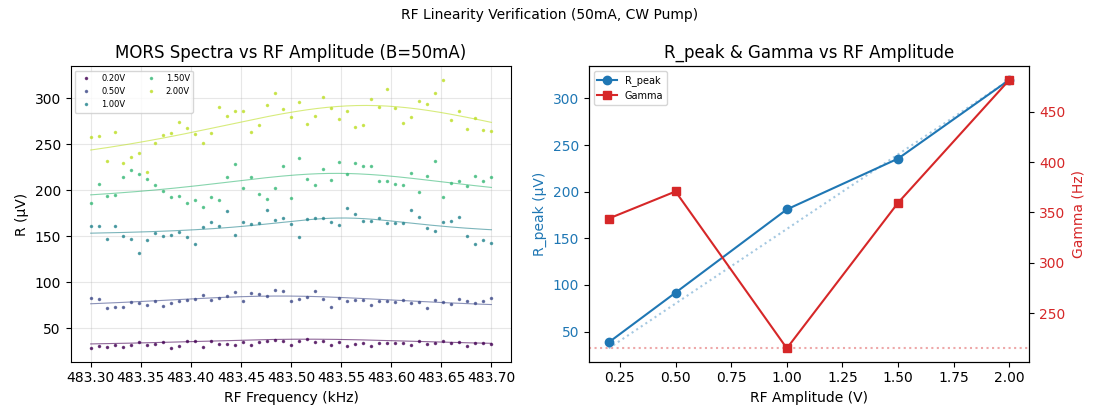


RF 线性区验证完成，B 已恢复到初始值


In [58]:

# ---- 结果汇总 ----
print(f"\n{'RF(V)':>7s} {'R_peak(V)':>12s} {'Gamma(Hz)':>11s} {'f0(kHz)':>10s}")
print("-" * 45)
for r in verify_results:
    print(f"{r['RF_amp_V']:7.3f} {r['R_peak_V']:12.4e} {r['Gamma_Hz']:11.1f} {r['f0_Hz']/1000:10.3f}")

# 线性区判断
amps_arr = np.array([r["RF_amp_V"] for r in verify_results])
gammas = np.array([r["Gamma_Hz"] for r in verify_results])
r_peaks = np.array([r["R_peak_V"] for r in verify_results])
valid_g = gammas[~np.isnan(gammas)]
if len(valid_g) >= 3:
    gamma_spread = np.max(valid_g) / np.min(valid_g)
    if gamma_spread < 1.2:
        print(f"\n  -> Gamma 变化 < 20% ({gamma_spread:.2f}x)，全范围在线性区。")
        print(f"  -> 可选 RF_AMPLITUDE = {RF_AMP_TEST[-1]} V (最大幅度, 最佳 SNR)")
    else:
        print(f"\n  -> Gamma 变化 {gamma_spread:.2f}x，需判断是否功率展宽。")

# =====================================================================
# 可视化: 谱叠加 + R_peak / Gamma vs RF 幅度
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# ---- 左: 各 RF 幅度的 MORS 谱 + 拟合 ----
ax_l = axes[0]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(verify_traces)))
for i, tr in enumerate(verify_traces):
    f_v = tr["freqs"]; r_v = tr["r"]
    valid = ~np.isnan(r_v)
    ax_l.plot(f_v[valid]/1000, r_v[valid]*1e6, '.', color=colors[i], ms=3, alpha=0.7,
              label=f'{tr["amp"]:.2f}V')
    # 拟合曲线
    r_fit = verify_results[i]
    if not np.isnan(r_fit["Gamma_Hz"]):
        f_plot = np.linspace(f_v[0], f_v[-1], 200)
        r_plot = _lor(f_plot, r_fit["A"], r_fit["f0_Hz"], r_fit["Gamma_Hz"], r_fit["offset"])
        ax_l.plot(f_plot/1000, r_plot*1e6, '-', color=colors[i], lw=0.8, alpha=0.6)
ax_l.set_xlabel('RF Frequency (kHz)')
ax_l.set_ylabel('R (μV)')
ax_l.set_title(f'MORS Spectra vs RF Amplitude (B=50mA)')
ax_l.legend(fontsize=6, ncol=2)
ax_l.grid(True, alpha=0.3)

# ---- 右: R_peak 和 Gamma vs RF 幅度 ----
ax_r1 = axes[1]
ax_r2 = ax_r1.twinx()
mask_ok = ~np.isnan(gammas)
# R_peak vs RF
line1, = ax_r1.plot(amps_arr[mask_ok], r_peaks[mask_ok]*1e6, 'C0o-', ms=6, label='R_peak')
ax_r1.set_xlabel('RF Amplitude (V)')
ax_r1.set_ylabel('R_peak (μV)', color='C0')
ax_r1.tick_params(axis='y', labelcolor='C0')
# Gamma vs RF
line2, = ax_r2.plot(amps_arr[mask_ok], gammas[mask_ok], 'C3s-', ms=6, label='Gamma')
ax_r2.set_ylabel('Gamma (Hz)', color='C3')
ax_r2.tick_params(axis='y', labelcolor='C3')
# 参考线: Gamma = const
if len(valid_g) >= 2:
    gamma_ref = np.nanmin(gammas)  # 取最小 Gamma 作为参考（最高 SNR 时最准确）
    ax_r2.axhline(gamma_ref, color='C3', ls=':', alpha=0.4)
    # R ∝ V_rf 参考线
    if r_peaks[mask_ok][-1] > 0:
        slope = r_peaks[mask_ok][-1] / amps_arr[mask_ok][-1]
        ax_r1.plot(amps_arr[mask_ok], slope * amps_arr[mask_ok]*1e6, 'C0:', alpha=0.4)
ax_r1.set_title('R_peak & Gamma vs RF Amplitude')
lines = [line1, line2]
ax_r1.legend(lines, [l.get_label() for l in lines], fontsize=7, loc='upper left')

fig.suptitle('RF Linearity Verification (50mA, CW Pump)', fontsize=10)
fig.tight_layout()
fig.savefig(results_dir / "rf_linearity_verification.png", dpi=150, bbox_inches="tight")
plt.show()

# 恢复初始 B
gs.set_current(B_CURRENT_mA[0] / 1000.0)
print("\nRF 线性区验证完成，B 已恢复到初始值")

In [ ]:
# =====================================================================
# 主测量: 扫描 B 场，每个 B 值下窄扫 RF 频率 → 记录 MORS 单峰
# =====================================================================

print("=" * 60)
print("主测量: RF 线圈扫频 MORS")
print(f"  B 扫描点: {len(B_CURRENT_mA)} 个")
print(f"  RF 扫频: +/-{RF_SWEEP_HALF_SPAN} Hz, {RF_SWEEP_POINTS} 点")
print(f"  每点等待: {SETTLE_MULTIPLIER}xTC={SETTLE_MULTIPLIER*HF2_DEMOD_TC*1e3:.0f} ms")
print(f"  每点采样: {N_SAMPLES_PER_POINT} 次")
print("=" * 60)

all_results = []

try:
    for i_b, I_mA in enumerate(B_CURRENT_mA):
        nu_L = calc_nu_L(I_mA)
        print(f"\n--- B point {i_b+1}/{len(B_CURRENT_mA)}: I={I_mA:.2f} mA, nu_L={nu_L/1000:.1f} kHz ---")

        # ---- 设置主磁场 ----
        validate_safety_limit("main_magnetic_field", float(I_mA))
        gs.set_current(I_mA / 1000.0)
        time.sleep(0.5)

        # ---- 设置 HF2 参考频率 ----
        demod.set_reference_frequency(hfi, nu_L, osc_idx=0)
        time.sleep(0.1)

        # ---- 生成 RF 扫频序列 ----
        rf_freqs = np.linspace(
            nu_L - RF_SWEEP_HALF_SPAN,
            nu_L + RF_SWEEP_HALF_SPAN,
            RF_SWEEP_POINTS
        )
        r_values = np.full(RF_SWEEP_POINTS, np.nan)
        r_stds = np.full(RF_SWEEP_POINTS, np.nan)

        # ---- 初始 RF 设置，打开输出 ----
        dg_rf.setup_sine(freq=rf_freqs[0], amplitude=RF_AMPLITUDE, offset=0.0)
        dg_rf.set_output(True)


        # ---- 逐点扫频 ----
        for j, f_rf in enumerate(tqdm(rf_freqs, desc=f"  B={I_mA:.1f}mA", unit="pt", leave=False)):
            # 更新 RF 频率
            dg_rf.set_frequency(f_rf)
            # ---- 关闭温度开关 (一次性，整个 B 点扫频期间关闭) ----
            dg_temp.set_output(False, channel=2)
            # ---- 等待首次稳定 ----
            time.sleep(SETTLE_MULTIPLIER * HF2_DEMOD_TC)
            # 多次采样取均值
            samples = []
            for _ in range(N_SAMPLES_PER_POINT):
                sample = demod.read_demod_sample(hfi, demod_idx=HF2_DEMOD_IDX)
                samples.append(sample["r"])
                time.sleep(HF2_DEMOD_TC)
            r_values[j] = np.mean(samples)
            r_stds[j] = np.std(samples, ddof=1) if N_SAMPLES_PER_POINT > 1 else 0.0

            # ---- 恢复温度开关 (一次性，扫频结束后) ----
            dg_temp.set_output(True, channel=2)
            time.sleep(2)  # 等待温控 PWM 恢复

        # ---- 关闭 RF 输出 ----
        dg_rf.set_output(False)

        # ---- 保存 ----
        result = {
            "I_mA": I_mA,
            "nu_L_theory_Hz": nu_L,
            "rf_freqs_Hz": rf_freqs,
            "r_values_V": r_values,
            "r_stds_V": r_stds,
            "n_samples": N_SAMPLES_PER_POINT,
        }
        all_results.append(result)

        np.savez(
            raw_dir / f"mors_rf_I{I_mA:.2f}mA.npz",
            I_mA=I_mA, nu_L_theory_Hz=nu_L,
            rf_freqs_Hz=rf_freqs,
            r_values_V=r_values, r_stds_V=r_stds,
            n_samples=N_SAMPLES_PER_POINT,
        )
        print(f"  -> R peak={np.nanmax(r_values):.4e} V, mean sigma_R={np.nanmean(r_stds):.3e} V")

except Exception as e:
    print(f"\n测量出错: {e}")
    try:
        dg_rf.set_output(False)
        dg_temp.set_output(True, channel=2)
        gs.set_current(B_CURRENT_mA[0] / 1000.0)
    except Exception:
        pass
    raise

finally:
    dg_rf.set_output(False)
    dg_temp.set_output(True, channel=2)
    print("RF 输出已关闭，温度开关已恢复")

print(f"\n主测量完成，共 {len(all_results)} 个 B 点")

In [24]:
# =====================================================================
# 数据分析: Lorentzian 拟合每个 B 点的 MORS 单峰 → 提取 Γ, 中心频率
# =====================================================================

# 吸收型 Lorentzian (FWHM = Gamma)
def lorentzian(f, A, f0, Gamma, offset):
    """R(f) = A * (Γ/2)² / [(f-f0)² + (Γ/2)²] + offset,  FWHM = Γ"""
    h = Gamma / 2.0
    return A * h**2 / ((f - f0)**2 + h**2) + offset

# 存储拟合结果
fit_results = []

for i, res in enumerate(all_results):
    f = res["rf_freqs_Hz"]
    r = res["r_values_V"]
    nu_L_theory = res["nu_L_theory_Hz"]

    # 去除 NaN
    valid = ~np.isnan(r)
    f_valid = f[valid]
    r_valid = r[valid]

    if len(f_valid) < 10:
        print(f"  B={res['I_mA']:.1f}mA: 有效数据点不足，跳过拟合")
        fit_results.append({"I_mA": res["I_mA"], "fit_ok": False})
        continue

    # 初始估计
    r_max = np.max(r_valid)
    r_min = np.min(r_valid)
    f_peak = f_valid[np.argmax(r_valid)]
    offset_est = np.median(r_valid[:10])  # 用边缘点估计基线
    A_est = r_max - offset_est
    # 半高全宽估计: 找到 R > offset + A/2 的频率范围
    half_thresh = offset_est + A_est * 0.5
    above_half = r_valid > half_thresh
    if np.sum(above_half) >= 2:
        fwhm_est = f_valid[above_half][-1] - f_valid[above_half][0]
    else:
        fwhm_est = 500.0
    Gamma_est = max(fwhm_est, 10.0)

    p0 = [A_est, f_peak, Gamma_est, offset_est]
    bounds = (
        [0, f_valid[0], 10.0, 0],
        [r_max * 10, f_valid[-1], fwhm_est * 10, r_max],
    )

    try:
        popt, pcov = curve_fit(
            lorentzian, f_valid, r_valid,
            p0=p0, bounds=bounds, maxfev=10000,
        )
        A_fit, f0_fit, Gamma_fit, offset_fit = popt
        perr = np.sqrt(np.diag(pcov))
        Gamma_err = perr[2]

        # 计算 R²
        r_pred = lorentzian(f_valid, *popt)
        ss_res = np.sum((r_valid - r_pred) ** 2)
        ss_tot = np.sum((r_valid - np.mean(r_valid)) ** 2)
        r_squared = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

        fit_results.append({
            "I_mA": res["I_mA"],
            "nu_L_theory_Hz": nu_L_theory,
            "fit_ok": True,
            "A": A_fit, "f0_Hz": f0_fit, "Gamma_Hz": Gamma_fit,
            "Gamma_err_Hz": Gamma_err, "offset": offset_fit,
            "r_squared": r_squared,
            "freqs": f_valid, "r_data": r_valid,
        })
        print(f"  B={res['I_mA']:.1f}mA: f0={f0_fit/1000:.3f} kHz, Γ={Gamma_fit:.1f}±{Gamma_err:.1f} Hz, R²={r_squared:.4f}")

    except Exception as e:
        print(f"  B={res['I_mA']:.1f}mA: 拟合失败 ({e})")
        fit_results.append({"I_mA": res["I_mA"], "fit_ok": False})

# 提取成功拟合的结果
ok_results = [r for r in fit_results if r.get("fit_ok")]
print(f"\n拟合完成: {len(ok_results)}/{len(fit_results)} 成功")

  B=10.0mA: f0=91.799 kHz, Γ=18539.3±89532.1 Hz, R²=0.0376
  B=20.0mA: f0=197.381 kHz, Γ=8184.8±7765.5 Hz, R²=-0.0870
  B=30.0mA: f0=290.959 kHz, Γ=5370.0±971.6 Hz, R²=0.6585
  B=40.0mA: f0=386.080 kHz, Γ=10315.1±11953.9 Hz, R²=0.0987
  B=50.0mA: f0=486.131 kHz, Γ=34336.7±663978.1 Hz, R²=0.0060

拟合完成: 5/5 成功


In [25]:
# =====================================================================
# 外推分析: Γ(B) → 找 ν_s = 2Γ 的交叉点
# =====================================================================

if len(ok_results) < 2:
    print("成功拟合的点不足，无法外推。")
else:
    # 提取数据
    I_arr = np.array([r["I_mA"] for r in ok_results])
    nu_L_arr = np.array([r["nu_L_theory_Hz"] for r in ok_results])  # Hz
    Gamma_arr = np.array([r["Gamma_Hz"] for r in ok_results])
    Gamma_err_arr = np.array([r["Gamma_err_Hz"] for r in ok_results])

    print("=" * 60)
    print("Γ vs ν_L 数据分析")
    print("=" * 60)

    # ---- 模型 1: Γ = Γ₀ (常数, 均匀展宽主导) ----
    Gamma_mean = np.mean(Gamma_arr)
    Gamma_std = np.std(Gamma_arr)
    print(f"\n[模型 1] 常数 Γ: mean = {Gamma_mean:.1f} Hz, std = {Gamma_std:.1f} Hz")
    print(f"  → 若 Γ 为常数, 需 ν_s = 2Γ = {2*Gamma_mean:.1f} Hz")
    # ν_s = ν_L² / (2 * ν_hfs) → ν_L = sqrt(2 * ν_hfs * ν_s_target)
    nu_L_needed_1 = np.sqrt(2 * NU_HFS * 2 * Gamma_mean)
    B_needed_1 = nu_L_needed_1 / GYRO_RATIO
    # I = (ν_L - NU_RESIDUAL) / COIL_CONSTANT
    I_needed_1 = (nu_L_needed_1 - NU_RESIDUAL) / COIL_CONSTANT
    print(f"  → 需要 ν_L = {nu_L_needed_1/1000:.1f} kHz, B = {B_needed_1:.2f} G, I ≈ {I_needed_1:.0f} mA")

    # ---- 模型 2: Γ = Γ₀ + α·ν_L (线性, 含不均匀展宽) ----
    # 线性拟合 Γ = a * ν_L + b
    try:
        popt_lin, pcov_lin = np.polyfit(nu_L_arr, Gamma_arr, 1, w=1.0/np.maximum(Gamma_err_arr, 0.1), cov=True)
        a_lin = popt_lin[0]  # 斜率 (Hz/Hz)
        b_lin = popt_lin[1]  # 截距 (Hz)
        a_err = np.sqrt(pcov_lin[0, 0]) if pcov_lin.size > 0 else np.nan
        b_err = np.sqrt(pcov_lin[1, 1]) if pcov_lin.size > 0 else np.nan

        print(f"\n[模型 2] Γ = a·ν_L + b")
        print(f"  a = {a_lin:.2e} ± {a_err:.2e} (Hz/Hz)")
        print(f"  b = {b_lin:.1f} ± {b_err:.1f} Hz")

        if a_lin > a_err:  # 斜率显著
            print(f"  → 不均匀展宽显著 (a > 0)")
        else:
            print(f"  → 均匀展宽主导 (a ≈ 0), 可用模型 1 的结论")

        # 解方程: ν_L² / (2 * ν_hfs) = 2 * (a·ν_L + b)
        # → ν_L² - 4·a·ν_hfs·ν_L - 4·b·ν_hfs = 0
        A = 1.0
        B_coeff = -4.0 * a_lin * NU_HFS
        C = -4.0 * b_lin * NU_HFS
        discriminant = B_coeff**2 - 4 * A * C
        if discriminant > 0:
            nu_L_needed_2 = (-B_coeff + np.sqrt(discriminant)) / (2 * A)
            B_needed_2 = nu_L_needed_2 / GYRO_RATIO
            I_needed_2 = (nu_L_needed_2 - NU_RESIDUAL) / COIL_CONSTANT
            print(f"  → 解方程 ν_s = 2Γ: ν_L = {nu_L_needed_2/1000:.1f} kHz, B = {B_needed_2:.2f} G, I ≈ {I_needed_2:.0f} mA")
        else:
            nu_L_needed_2 = np.nan
            print(f"  → 方程无实数解 (ν_s 在所有 ν_L 下都小于 2Γ)")

    except Exception as e:
        print(f"  线性拟合失败: {e}")
        a_lin, b_lin, nu_L_needed_2 = np.nan, np.nan, np.nan

    # ---- 外推曲线 ----
    nu_L_ext = np.logspace(
        np.log10(max(nu_L_arr[0] * 0.5, 1e3)),
        np.log10(max(nu_L_needed_1 * 2, nu_L_arr[-1] * 10, 1e7)),
        200
    )
    nu_s_ext = nu_L_ext**2 / (2 * NU_HFS)  # Hz
    Gamma_ext_const = np.full_like(nu_L_ext, Gamma_mean)
    Gamma_ext_lin = a_lin * nu_L_ext + b_lin if not np.isnan(a_lin) else Gamma_ext_const

    # ---- 保存分析结果 ----
    analysis = {
        "model_1_constant_gamma": {
            "Gamma_mean_Hz": float(Gamma_mean),
            "Gamma_std_Hz": float(Gamma_std),
            "nu_L_needed_Hz": float(nu_L_needed_1),
            "B_needed_G": float(B_needed_1),
            "I_needed_mA": float(I_needed_1),
        },
        "model_2_linear_gamma": {
            "a": float(a_lin) if not np.isnan(a_lin) else None,
            "b_Hz": float(b_lin) if not np.isnan(b_lin) else None,
            "nu_L_needed_Hz": float(nu_L_needed_2) if not np.isnan(nu_L_needed_2) else None,
            "B_needed_G": float(B_needed_2) if not np.isnan(nu_L_needed_2) else None,
            "I_needed_mA": float(I_needed_2) if not np.isnan(nu_L_needed_2) else None,
        },
        "raw_data": {
            "I_mA": I_arr.tolist(),
            "nu_L_Hz": nu_L_arr.tolist(),
            "Gamma_Hz": Gamma_arr.tolist(),
            "Gamma_err_Hz": Gamma_err_arr.tolist(),
        },
    }
    analysis_path = results_dir / "feasibility_analysis.yaml"
    with open(analysis_path, "w", encoding="utf-8") as f:
        yaml.dump(analysis, f, default_flow_style=False, allow_unicode=True)
    print(f"\n分析结果已保存: {analysis_path}")

Γ vs ν_L 数据分析

[模型 1] 常数 Γ: mean = 15349.2 Hz, std = 10459.0 Hz
  → 若 Γ 为常数, 需 ν_s = 2Γ = 30698.4 Hz
  → 需要 ν_L = 20485.3 kHz, B = 29.26 G, I ≈ 2118 mA

[模型 2] Γ = a·ν_L + b
  a = -6.24e-03 ± 2.15e-02 (Hz/Hz)
  b = 7250.2 ± 6223.5 Hz
  → 均匀展宽主导 (a ≈ 0), 可用模型 1 的结论
  → 解方程 ν_s = 2Γ: ν_L = 1154.8 kHz, B = 1.65 G, I ≈ 119 mA

分析结果已保存: d:\Code\exp_agent\data\MORS_feasibility\0528_1313_linewidth_vs_B\results\feasibility_analysis.yaml


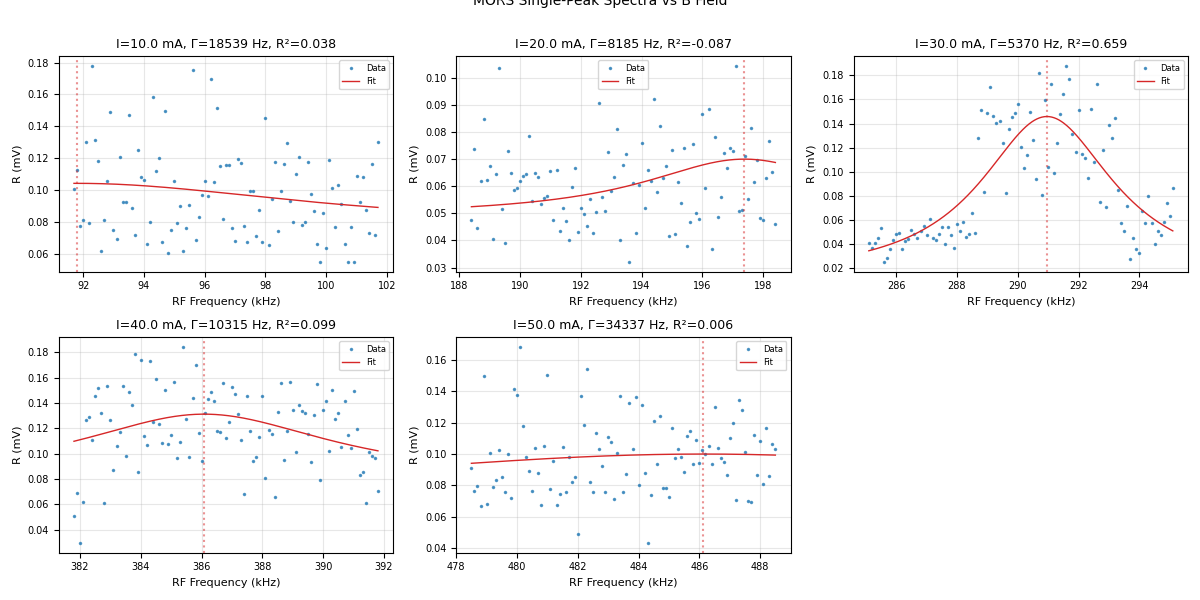

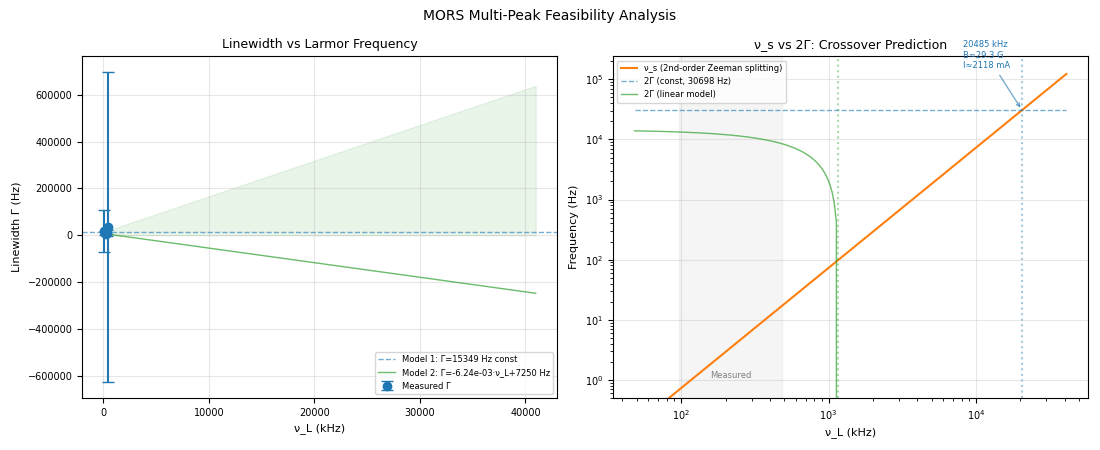


可行性判断
模型 1 (常数 Γ): 需 I ≈ 2118 mA, B ≈ 29.3 G
模型 2 (线性 Γ): 需 I ≈ 119 mA, B ≈ 1.6 G

GS200 当前安全上限: 51 mA

*** 所需电流超出当前安全范围。如需进行 MORS 多峰测量，请确认:
    1. 线圈能否承受 2118 mA 电流而不发热?
    2. GS200 是否配置在 200 mA 量程?
    3. 更新 safety_limits.yaml 中的 main_magnetic_field 上限 ***


In [26]:
# =====================================================================
# 可视化: MORS 谱 + Γ vs ν_L + 外推
# =====================================================================

plt.close('all')

_rc_backup = {k: plt.rcParams[k] for k in ['font.size', 'axes.titlesize', 'axes.labelsize',
                                             'xtick.labelsize', 'ytick.labelsize', 'legend.fontsize']}
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9, 'axes.labelsize': 8,
                     'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7})

# =====================================================================
# Figure 1: 各 B 点的 MORS 谱 + Lorentzian 拟合
# =====================================================================
n_plots = len(ok_results)
if n_plots > 0:
    n_cols = min(3, n_plots)
    n_rows = int(np.ceil(n_plots / n_cols))

    fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    if n_plots == 1:
        axes1 = np.array([axes1])
    axes1 = np.atleast_1d(axes1).flatten()

    for i, r in enumerate(ok_results):
        ax = axes1[i]
        ax.plot(r["freqs"]/1000, r["r_data"]*1e3, '.', color='C0', ms=3, alpha=0.7, label='Data')
        f_plot = np.linspace(r["freqs"][0], r["freqs"][-1], 500)
        r_plot = lorentzian(f_plot, r["A"], r["f0_Hz"], r["Gamma_Hz"], r["offset"])
        ax.plot(f_plot/1000, r_plot*1e3, 'C3-', lw=1.0, label='Fit')
        ax.axvline(r["f0_Hz"]/1000, color='C3', ls=':', alpha=0.5)
        ax.set_xlabel('RF Frequency (kHz)')
        ax.set_ylabel('R (mV)')
        ax.set_title(f"I={r['I_mA']:.1f} mA, Γ={r['Gamma_Hz']:.0f} Hz, R²={r['r_squared']:.3f}")
        ax.legend(fontsize=6)
        ax.grid(True, alpha=0.3)

    for j in range(n_plots, len(axes1)):
        axes1[j].set_visible(False)

    fig1.suptitle('MORS Single-Peak Spectra vs B Field', fontsize=10, y=1.01)
    fig1.tight_layout()
    fig1.savefig(results_dir / "mors_spectra_vs_B.png", dpi=150, bbox_inches="tight")
    plt.show()

# =====================================================================
# Figure 2: Γ vs ν_L + 外推 (核心结果图)
# =====================================================================
if len(ok_results) >= 2:
    fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4.5))

    # ---- 左: Γ vs ν_L (实测 + 两种模型) ----
    ax_l = axes2[0]
    ax_l.errorbar(nu_L_arr/1000, Gamma_arr, yerr=Gamma_err_arr,
                  fmt='o', color='C0', capsize=4, ms=6, label='Measured Γ')
    ax_l.axhline(Gamma_mean, color='C0', ls='--', lw=1.0, alpha=0.6,
                 label=f'Model 1: Γ={Gamma_mean:.0f} Hz const')
    if not np.isnan(a_lin):
        ax_l.plot(nu_L_ext/1000, Gamma_ext_lin, 'C2-', lw=1.0, alpha=0.7,
                  label=f'Model 2: Γ={a_lin:.2e}·ν_L+{b_lin:.0f} Hz')
        ax_l.fill_between(nu_L_ext/1000,
                          np.maximum(Gamma_ext_lin - a_err*nu_L_ext - b_err, 0),
                          Gamma_ext_lin + a_err*nu_L_ext + b_err,
                          color='C2', alpha=0.1)
    ax_l.set_xlabel('ν_L (kHz)')
    ax_l.set_ylabel('Linewidth Γ (Hz)')
    ax_l.set_title('Linewidth vs Larmor Frequency')
    ax_l.legend(fontsize=6)
    ax_l.grid(True, alpha=0.3)

    # ---- 右: ν_s vs ν_L + 2Γ vs ν_L (找交叉点) ----
    ax_r = axes2[1]
    ax_r.loglog(nu_L_ext/1000, nu_s_ext, 'C1-', lw=1.5, label='ν_s (2nd-order Zeeman splitting)')
    ax_r.loglog(nu_L_ext/1000, 2*Gamma_ext_const, 'C0--', lw=1.0, alpha=0.6,
                label=f'2Γ (const, {2*Gamma_mean:.0f} Hz)')
    if not np.isnan(a_lin):
        ax_r.loglog(nu_L_ext/1000, 2*Gamma_ext_lin, 'C2-', lw=1.0, alpha=0.7,
                    label=f'2Γ (linear model)')
    # 标注交叉点
    ax_r.axvline(nu_L_needed_1/1000, color='C0', ls=':', alpha=0.4)
    ax_r.annotate(f'{nu_L_needed_1/1000:.0f} kHz\nB≈{B_needed_1:.1f} G\nI≈{I_needed_1:.0f} mA',
                  xy=(nu_L_needed_1/1000, 2*Gamma_mean),
                  xytext=(nu_L_needed_1/1000*0.4, 2*Gamma_mean*5),
                  arrowprops=dict(arrowstyle='->', color='C0', alpha=0.6),
                  fontsize=6, color='C0')
    if not np.isnan(nu_L_needed_2):
        ax_r.axvline(nu_L_needed_2/1000, color='C2', ls=':', alpha=0.4)
    # 实测数据范围标记
    ax_r.axvspan(nu_L_arr[0]/1000, nu_L_arr[-1]/1000, color='gray', alpha=0.08)
    ax_r.text(np.sqrt(nu_L_arr[0]*nu_L_arr[-1])/1000, 1, 'Measured',
              fontsize=6, ha='center', va='bottom', color='gray')
    ax_r.set_xlabel('ν_L (kHz)')
    ax_r.set_ylabel('Frequency (Hz)')
    ax_r.set_title('ν_s vs 2Γ: Crossover Prediction')
    ax_r.legend(fontsize=6)
    ax_r.grid(True, alpha=0.3)
    ax_r.set_ylim(bottom=0.5)

    fig2.suptitle('MORS Multi-Peak Feasibility Analysis', fontsize=10)
    fig2.tight_layout()
    fig2.savefig(results_dir / "feasibility_extrapolation.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ---- 结论 ----
    print("\n" + "=" * 60)
    print("可行性判断")
    print("=" * 60)
    print(f"模型 1 (常数 Γ): 需 I ≈ {I_needed_1:.0f} mA, B ≈ {B_needed_1:.1f} G")
    if not np.isnan(a_lin):
        print(f"模型 2 (线性 Γ): 需 I ≈ {I_needed_2:.0f} mA, B ≈ {B_needed_2:.1f} G")
    gs200_max = LIMITS['main_magnetic_field']['max']
    print(f"\nGS200 当前安全上限: {gs200_max} mA")
    if I_needed_1 < gs200_max:
        print(f"\n*** 模型 1 所需电流在安全范围内，可在当前磁场扫描中直接观察到多峰分裂！***")
    else:
        print(f"\n*** 所需电流超出当前安全范围。如需进行 MORS 多峰测量，请确认:")
        print(f"    1. 线圈能否承受 {I_needed_1:.0f} mA 电流而不发热?")
        print(f"    2. GS200 是否配置在 200 mA 量程?")
        print(f"    3. 更新 safety_limits.yaml 中的 main_magnetic_field 上限 ***")

plt.rcParams.update(_rc_backup)

In [59]:
# ========== 安全断开 ==========

print("正在断开设备...")

# 恢复主磁场到起始值
try:
    gs.set_current(B_CURRENT_mA[0] / 1000.0)
    print(f"  主磁场已恢复: {B_CURRENT_mA[0]} mA")
except Exception as e:
    print(f"  恢复磁场失败: {e}")

for name, dev in devices.items():
    if hasattr(dev, "disconnect"):
        try:
            dev.disconnect()
            print(f"  {name} 已断开")
        except Exception as e:
            print(f"  {name} 断开失败: {e}")

print("所有设备已断开")

正在断开设备...
  主磁场已恢复: 10.0 mA
  gs200 已断开
  dg_laser 已断开
  dg_rf 已断开
  dg_mod 已断开
  dg_temp 已断开
  tec 已断开
  hf2 已断开
所有设备已断开
